In [1]:
import pandas as pd
import numpy as np
import re
import json
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('_dataset.csv')

In [3]:
duplicates = df.duplicated().sum()

if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Removing duplicates...")
    df = df.drop_duplicates()
    df.to_csv('_dataset.csv', index=False)
    print("Duplicates removed and dataset updated.")

else:
    print("No duplicates found.")

No duplicates found.


### Handle Duplicates

In [4]:
print("Number of duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

Number of duplicates: 0


### Data Cleaning 

In [5]:
def fill_missing(df, col):
    missing_pct = df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing", end=" → ")

    # Drop if more than 50% missing
    if missing_pct > 50:
        df.drop(columns=[col], inplace=True)
        print("❌ Dropped (>50% missing)")

    # Between 30% and 50% — drop rows
    elif missing_pct > 30:
        df.dropna(subset=[col], inplace=True)
        print("🗑️ Dropped rows (30-50% missing)")

    # Between 10% and 30% — fill with mean/mode + add indicator column
    elif missing_pct > 10:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].mean()
            strategy = f"mean ({fill_val:.2f})"

        df[f'{col}_was_missing'] = df[col].isnull().astype(int)  # indicator column
        df[col].fillna(fill_val, inplace=True)
        print(f"⚠️ Filled with {strategy} + added indicator column (10-30% missing)")

    # Less than 10% — fill with median/mode
    elif missing_pct > 0:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].median()
            strategy = f"median ({fill_val:.2f})"

        df[col].fillna(fill_val, inplace=True)
        print(f"✅ Filled with {strategy} (<10% missing)")

    else:
        print("✅ No missing values")

    return df


### Target Encoding Function

In [6]:
def weighted_target_encoding(df, feature, target, m=10):
    
    global_mean = df[target].mean()
    
    stats = df.groupby(feature)[target].agg(['mean', 'count'])
    
    stats['weighted_mean'] = (
        stats['mean'] * stats['count'] + global_mean * m
    ) / (stats['count'] + m)
    
    mapping = stats['weighted_mean'].to_dict()
    
    encoded_feature = df[feature].map(mapping)
    
    return encoded_feature, mapping

In [7]:
df['city'].value_counts()

city
Mumbai        1547
Bangalore     1421
Ahmedabad     1068
Hyderabad     1000
Noida          991
Jaipur         856
Chennai        824
Chandigarh     381
Name: count, dtype: int64

0. Price

In [8]:
def clean_price(x):
    x = str(x).replace("₹", "").strip()

    if "Lakh" in x:
        return float(x.replace("Lakh", "").strip()) * 100000

    elif "Crore" in x:
        return float(x.replace("Crore", "").strip()) * 10000000

    elif "Thousand" in x:
        return float(x.replace("Thousand", "").strip()) * 1000

    else:
        return None


df["Price"] = df["Price"].apply(clean_price)

In [9]:
df = fill_missing(df, 'Price') 

Price: 0.70% missing → ✅ Filled with median (608000.00) (<10% missing)


0. City

In [10]:
df['city'], city_mapping = weighted_target_encoding(
    df,
    feature='city',
    target='Price',
    m=20
)

In [11]:
df['city'].value_counts()

city
1.275620e+06    1547
1.043789e+06    1421
6.003726e+05    1068
1.058013e+06    1000
1.605622e+06     991
8.910997e+05     856
8.316900e+05     824
1.625248e+06     381
Name: count, dtype: int64

1. 'car_name'

In [12]:
df = fill_missing(df, 'car_name')

car_name: 0.00% missing → ✅ No missing values


In [13]:
def clean_car_name(df, city):
    # remove extra spaces
    df['car_name'] = df['car_name'].str.strip()

    # remove rows that contain scraping phrases
    pattern = rf"used cars for sale|in {city}|₹"
    df = df[~df['car_name'].str.contains(pattern, case=False, na=False)]

    # keep only names that start with letters
    df = df[df['car_name'].str.match(r'^[A-Za-z]', na=False)]

    return df

In [14]:
for city in df['city'].unique():
    df = clean_car_name(df, city)

df[['brand', 'model']] = df['car_name'].str.split(' ', n=1, expand=True)

In [15]:
df['model'].nunique()

345

In [16]:
df['model'], model_mapping = weighted_target_encoding(
    df,
    feature="model",
    target="Price",
    m=20
)

df['brand'], brand_mapping = weighted_target_encoding(
    df,
    feature="brand",
    target="Price",
    m=20
)

In [17]:
df['model'].nunique()

332

In [18]:
invalid_brands = [
    'Era', 'HTX', 'LXI', 'S', 'Sportz', 'VX', 'VXI', 'XZ', 'i'
]

df = df[~df['brand'].isin(invalid_brands)]

In [19]:
df = df.drop(columns=['car_name'])

2. Registration Year

In [20]:
def clean_registration_year(x):
    if pd.isna(x):
        return None
    
    x = str(x)
    
    # extract 4-digit year
    match = re.search(r'\b(19|20)\d{2}\b', x)
    
    if match:
        return int(match.group())
    
    return None

In [21]:
df["Registration Year"] = df["Registration Year"].apply(clean_registration_year)

In [22]:
df = fill_missing(df, 'Registration Year')

Registration Year: 0.16% missing → ✅ Filled with median (2019.00) (<10% missing)


3. 'Kms Driven'

In [23]:
df["Kms Driven"] = (
    df["Kms Driven"]
    .str.replace("Kms", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')  # ✅ skips NaN, converts to float
)

In [24]:
df = fill_missing(df, 'Kms Driven')

Kms Driven: 0.02% missing → ✅ Filled with median (60000.00) (<10% missing)


4. 'Ownership'

In [25]:
ownership_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth Owner": 4,
    "Fifth Owner": 5
}

df["Ownership"] = df["Ownership"].map(ownership_map)
df = fill_missing(df, 'Ownership')

Ownership: 0.19% missing → ✅ Filled with median (1.00) (<10% missing)


5. 'Fuel'

In [26]:
df = fill_missing(df, 'Fuel')

Fuel: 13.82% missing → ⚠️ Filled with mode (Petrol) + added indicator column (10-30% missing)


In [27]:
# get sorted fuel categories
fuel_categories = sorted(df['Fuel'].dropna().unique())

print("All Fuel Categories:", fuel_categories)

# first category will be dropped
dropped_category = fuel_categories[0]
print("Dropped Category:", dropped_category)

# apply one hot encoding
fuel_dummies = pd.get_dummies(df['Fuel'], prefix="Fuel")

# drop the first category column
fuel_dummies.drop(f"Fuel_{dropped_category}", axis=1, inplace=True)

# merge with dataframe
df = pd.concat([df, fuel_dummies], axis=1)

# remove original column
df.drop(columns=['Fuel'], inplace=True)

All Fuel Categories: ['CNG', 'Diesel', 'LPG', 'Petrol']
Dropped Category: CNG


6. 'Transmission'

In [28]:
df = fill_missing(df, 'Transmission')

transmission_map = {
    "Automatic": 1,
    "Manual": 0
}

df["Transmission"] = df["Transmission"].map(transmission_map)


Transmission: 0.02% missing → ✅ Filled with mode (Manual) (<10% missing)


7. 'Drive Type'

In [29]:
def clean_drive_type(x):
    if pd.isna(x):
        return None
    
    x = str(x).strip().lower()

    if "fwd" in x or "front" in x:
        return "FWD"
    
    elif "rwd" in x:
        return "RWD"
    
    elif "awd" in x or "4wd" in x or "4x4" in x:
        return "AWD"
    
    elif "2wd" in x or "2 wd" in x or "two wheel" in x or "4x2" in x:
        return "FWD"
    
    else:
        return None


df["Drive Type"] = df["Drive Type"].apply(clean_drive_type)

In [30]:
df = fill_missing(df, 'Drive Type')

Drive Type: 12.77% missing → ⚠️ Filled with mode (FWD) + added indicator column (10-30% missing)


In [31]:
Drive_Type__categories = sorted(df['Drive Type'].dropna().unique())

print("All Fuel Categories:", Drive_Type__categories)

# first category will be dropped
dropped_category = Drive_Type__categories[0]
print("Dropped Category:", dropped_category)

# apply one hot encoding
Drive_Type_dummies = pd.get_dummies(df['Drive Type'], prefix="Drive_Type")

# drop the first category column
Drive_Type_dummies.drop(f"Drive_Type_{dropped_category}", axis=1, inplace=True)

# merge with dataframe
df = pd.concat([df, Drive_Type_dummies], axis=1)

# remove original column
df.drop(columns=['Drive Type'], inplace=True)

All Fuel Categories: ['AWD', 'FWD', 'RWD']
Dropped Category: AWD


8. 'Engine 

In [32]:
df["Engine"] = (
    df["Engine"]
    .str.replace("cc", "", regex=False)
    .str.strip()
    .astype(float)
)
df = fill_missing(df, 'Engine')

Engine: 1.02% missing → ✅ Filled with median (1353.00) (<10% missing)


9. Power

In [33]:
df["Power"] = (
    df["Power"]
    .str.replace("bhp", "", regex=False)
    .str.strip()
    .astype(float)
)
df = fill_missing(df, 'Power')

Power: 2.52% missing → ✅ Filled with median (100.60) (<10% missing)


10. Mileage

In [34]:
df["Mileage"] = (
    df["Mileage"]
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float)
)

df = fill_missing(df, 'Mileage')

Mileage: 13.33% missing → ⚠️ Filled with mean (19.12) + added indicator column (10-30% missing)


11. No. of Cylinders

In [35]:
df = fill_missing(df, 'No. of Cylinders')

No. of Cylinders: 0.75% missing → ✅ Filled with median (4.00) (<10% missing)


12. 'Turbo Charger'

In [36]:
df = fill_missing(df, 'Turbo Charger')
tubo_map = {
    "Yes": 1,
    "No": 0
}
df['Turbo Charger'] = df['Turbo Charger'].map(tubo_map)

Turbo Charger: 14.62% missing → ⚠️ Filled with mode (No) + added indicator column (10-30% missing)


13. Seats

In [37]:
df = fill_missing(df, 'Seats')

df["Seats"] = (
    df["Seats"]
    .str.replace("Seats", "", regex=False)
    .str.strip()
    .astype(float)
)

Seats: 0.37% missing → ✅ Filled with mode (5 Seats) (<10% missing)


14. Kerb Weight

In [38]:
df["Kerb Weight"] = (
    df["Kerb Weight"]
    .str.replace(r"[^\d]", "", regex=True)
)

# convert to numeric
df["Kerb Weight"] = pd.to_numeric(df["Kerb Weight"], errors="coerce")

# fill missing values
df = fill_missing(df, 'Kerb Weight')

Kerb Weight: 8.88% missing → ✅ Filled with median (1211.00) (<10% missing)


15. Ground Clearance Unladen

In [39]:
df["Ground Clearance Unladen"] = (
    df["Ground Clearance Unladen"]
    .str.replace("mm", "", regex=False)
    .str.strip()
    .astype(float)
)

df = fill_missing(df, 'Ground Clearance Unladen')

Ground Clearance Unladen: 36.55% missing → 🗑️ Dropped rows (30-50% missing)


16. ---

In [40]:
cols = [
    "Petrol Fuel Tank Capacity",
    "Diesel Fuel Tank Capacity",
    "CNG Fuel Tank Capacity"
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)  # keep numbers and decimal
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [41]:
petrol_median = df.loc[df["Fuel_Petrol"] == 1, "Petrol Fuel Tank Capacity"].median()

diesel_median = df.loc[df["Fuel_Diesel"] == 1, "Diesel Fuel Tank Capacity"].median()

cng_median = df.loc[
    (df["Fuel_Diesel"] == 0) & (df["Fuel_Petrol"] == 0),
    "CNG Fuel Tank Capacity"
].median()

In [42]:
df.loc[df["Fuel_Petrol"] == 1, "Petrol Fuel Tank Capacity"] = \
df.loc[df["Fuel_Petrol"] == 1, "Petrol Fuel Tank Capacity"].fillna(petrol_median)

In [43]:
df.loc[df["Fuel_Diesel"] == 1, "Diesel Fuel Tank Capacity"] = \
df.loc[df["Fuel_Diesel"] == 1, "Diesel Fuel Tank Capacity"].fillna(diesel_median)

In [44]:
df.loc[
    (df["Fuel_Diesel"] == 0) & (df["Fuel_Petrol"] == 0),
    "CNG Fuel Tank Capacity"
] = df.loc[
    (df["Fuel_Diesel"] == 0) & (df["Fuel_Petrol"] == 0),
    "CNG Fuel Tank Capacity"
].fillna(cng_median)

In [45]:
df[cols] = df[cols].fillna(0)

In [46]:
df.shape[0]

5082

---

In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [48]:
# Features and target
X = df.drop(columns=['Price'])
y = df['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [49]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [8, 12, 16],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5],
    'max_features'    : [0.6, 0.75, 0.85],
}

rf = RandomForestRegressor(
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,           
    verbose=2            
)

# # grid_search.fit(X_train, y_train)

# print("Best parameters:", grid_search.best_params_)
# print("Best CV R²:", round(grid_search.best_score_, 4))

In [50]:
print(len(X_train))

4065


In [51]:
X_train = X_train.sample(frac=1, random_state=42)
y_train = y_train.loc[X_train.index]

total = len(X_train)

batch_sizes = sorted(set([
    int(total * 0.40),
    int(total * 0.50),
    int(total * 0.60),
    int(total * 0.70),
    int(total * 0.80),
    int(total * 0.90),
    total
]))

train_scores, val_scores, actual_sizes = [], [], []

for size in batch_sizes:
    size = min(size, len(X_train))   

    X_batch = X_train.iloc[:size]
    y_batch = y_train.iloc[:size]

    model = RandomForestRegressor(
                n_estimators=500,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features=0.5,
                max_samples=0.7,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )
    
    model.fit(X_batch, y_batch)

    train_r2 = r2_score(y_batch, model.predict(X_batch))
    val_r2   = r2_score(y_test,  model.predict(X_test))

    train_scores.append(round(train_r2, 4))
    val_scores.append(round(val_r2, 4))
    actual_sizes.append(size)

    print(f"Rows: {size:>5} | Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

Rows:  1626 | Train R²: 0.7595 | Val R²: 0.5649
Rows:  2032 | Train R²: 0.7926 | Val R²: 0.5815
Rows:  2439 | Train R²: 0.8061 | Val R²: 0.6156
Rows:  2845 | Train R²: 0.8321 | Val R²: 0.6307
Rows:  3252 | Train R²: 0.8518 | Val R²: 0.6605
Rows:  3658 | Train R²: 0.8693 | Val R²: 0.6871
Rows:  4065 | Train R²: 0.4859 | Val R²: 0.7100


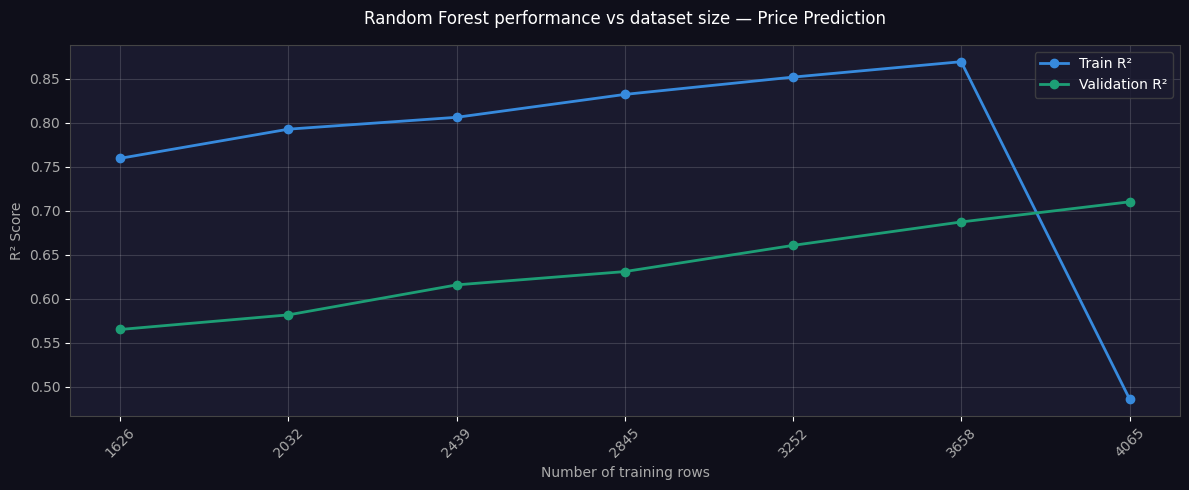

In [52]:
plt.style.use('dark_background')

plt.figure(figsize=(12, 5))
plt.plot(actual_sizes, train_scores, label='Train R²', marker='o', color='#378ADD', linewidth=2)
plt.plot(actual_sizes, val_scores,   label='Validation R²', marker='o', color='#1D9E75', linewidth=2)

plt.xlabel("Number of training rows", color='#aaaaaa')
plt.ylabel("R² Score", color='#aaaaaa')
plt.title("Random Forest performance vs dataset size — Price Prediction", color='white', pad=15)

plt.xticks(actual_sizes, rotation=45, color='#aaaaaa')
plt.yticks(color='#aaaaaa')

plt.gca().set_facecolor('#1a1a2e')
plt.gcf().set_facecolor('#0f0f1a')

plt.gca().spines['bottom'].set_color('#444444')
plt.gca().spines['left'].set_color('#444444')
plt.gca().spines['top'].set_color('#444444')
plt.gca().spines['right'].set_color('#444444')

plt.legend(facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')
plt.grid(True, alpha=0.15, color='#ffffff')
plt.tight_layout()
plt.show()

In [53]:
# import os
# import joblib

# os.makedirs("model", exist_ok=True)

# joblib.dump(best_model, "model/price_model.pkl")
# joblib.dump(brand_mapping, "model/brand_mapping.pkl")
# joblib.dump(model_mapping, "model/model_mapping.pkl")
# joblib.dump(city_mapping, 'model/city_mapping.pkl')

# print("Saved at:", os.path.abspath("model"))